# Notebook 04: Model Interpretability (SHAP)

## English
This notebook uses SHAP values to explain FinBERT predictions at token level and explore global importance trends.

**Goals:**
- Build a SHAP explainer for the fine-tuned model.
- Inspect local explanations for sample sentences.
- Review global token importance for the positive class.

## Espanol
Este notebook usa valores SHAP para explicar predicciones de FinBERT a nivel de tokens.

**Objetivos:**
- Construir un explainer SHAP para el modelo fine-tuned.
- Revisar explicaciones locales en frases ejemplo.
- Explorar importancia global de tokens para la clase positive.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import shap
from pathlib import Path
import numpy as np

device = 0 if torch.cuda.is_available() else -1
print("Device para SHAP:", device)

# %%
# 1. Cargar modelo y tokenizer finetuneados
MODEL_PATH = Path("../models/finbert_final")

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

clf_pipe = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
    top_k=None,  # devuelve scores de todas las clases
)

print("✅ Pipeline creado correctamente")

Device para SHAP: 0


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Pipeline creado correctamente


In [ ]:
# 2. Función de predicción para SHAP
labels = ["negative", "neutral", "positive"]


def pred_fn(texts):
    # SHAP a veces pasa arrays de numpy, los convertimos a lista de strings
    if not isinstance(texts, list):
        texts = texts.tolist()

    # Asegurarnos de que cada elemento sea un string
    texts = [str(t) for t in texts]

    outputs = clf_pipe(texts)

    # outputs es una lista de listas de dicts: [[{label, score}, ...], ...]
    scores = []
    for out in outputs:
        # Ordenamos por label para mantener el orden [negative, neutral, positive]
        out_sorted = sorted(out, key=lambda x: x["label"])
        scores.append([d["score"] for d in out_sorted])

    return np.array(scores)


# Prueba rápida
test_output = pred_fn(["This is a test sentence."])
print("✅ Función de predicción funciona:", test_output.shape)

✅ Función de predicción funciona: (1, 3)


In [34]:
# 3. Crear el explainer de texto
explainer = shap.Explainer(pred_fn, tokenizer, output_names=labels)
print("✅ Explainer creado")

✅ Explainer creado


In [ ]:
# 4. Frases de prueba
test_sentences = [
    "The company reported a significant increase in net profit compared to last year.",
    "Operating profit fell by 50% due to the global supply chain crisis.",
    "The stock price remained stable following the announcement of the new CEO.",
    "Sales were lower than expected, leading to a decrease in market share.",
]

print("Calculando valores SHAP (puede tardar 1-2 minutos)...")
shap_values = explainer(test_sentences)
print("✅ Valores SHAP calculados")

Calculando valores SHAP (puede tardar 1-2 minutos)...
✅ Valores SHAP calculados


### Results Visualization

## English
Red values indicate tokens that push the prediction toward the class.
Blue values indicate tokens that push the prediction away.

## Espanol
Los valores rojos indican palabras que empujan la prediccion hacia esa clase.
Los valores azules indican palabras que la alejan.

In [ ]:
# 5. Visualizaciones puntuales
for sent in test_sentences:
    # IMPORTANTE: pasar como lista para obtener formato consistente
    preds = clf_pipe([sent], top_k=None)[0]  # ← Nota los corchetes []
    print(f"\nTexto: {sent}")
    for p in sorted(preds, key=lambda x: x["label"]):
        print(f"  {p['label']:8s} -> {p['score']:.3f}")

print("\n" + "=" * 60)
print("Frase 1 (esperada: positive):")
print(test_sentences[0])
shap.plots.text(shap_values[0, :, "positive"])


Texto: The company reported a significant increase in net profit compared to last year.
  negative -> 0.024
  neutral  -> 0.017
  positive -> 0.959

Texto: Operating profit fell by 50% due to the global supply chain crisis.
  negative -> 0.867
  neutral  -> 0.117
  positive -> 0.017

Texto: The stock price remained stable following the announcement of the new CEO.
  negative -> 0.021
  neutral  -> 0.905
  positive -> 0.074

Texto: Sales were lower than expected, leading to a decrease in market share.
  negative -> 0.848
  neutral  -> 0.124
  positive -> 0.028

Frase 1 (esperada: positive):
The company reported a significant increase in net profit compared to last year.


In [ ]:
for sent in test_sentences:
    preds = clf_pipe([sent], top_k=None)[0]
    print(f"\nTexto: {sent}")
    for p in sorted(preds, key=lambda x: x["label"]):
        print(f"  {p['label']:8s} -> {p['score']:.3f}")

print("Frase 2 (esperada: negative):")
print(test_sentences[1])
shap.plots.text(shap_values[1, :, "negative"])


Texto: The company reported a significant increase in net profit compared to last year.
  negative -> 0.024
  neutral  -> 0.017
  positive -> 0.959

Texto: Operating profit fell by 50% due to the global supply chain crisis.
  negative -> 0.867
  neutral  -> 0.117
  positive -> 0.017

Texto: The stock price remained stable following the announcement of the new CEO.
  negative -> 0.021
  neutral  -> 0.905
  positive -> 0.074

Texto: Sales were lower than expected, leading to a decrease in market share.
  negative -> 0.848
  neutral  -> 0.124
  positive -> 0.028
Frase 2 (esperada: negative):
Operating profit fell by 50% due to the global supply chain crisis.


In [ ]:
for sent in test_sentences:
    preds = clf_pipe([sent], top_k=None)[0]
    print(f"\nTexto: {sent}")
    for p in sorted(preds, key=lambda x: x["label"]):
        print(f"  {p['label']:8s} -> {p['score']:.3f}")

print("Frase 3 (esperada: neutral):")
print(test_sentences[2])
shap


Texto: The company reported a significant increase in net profit compared to last year.
  negative -> 0.024
  neutral  -> 0.017
  positive -> 0.959

Texto: Operating profit fell by 50% due to the global supply chain crisis.
  negative -> 0.867
  neutral  -> 0.117
  positive -> 0.017

Texto: The stock price remained stable following the announcement of the new CEO.
  negative -> 0.021
  neutral  -> 0.905
  positive -> 0.074

Texto: Sales were lower than expected, leading to a decrease in market share.
  negative -> 0.848
  neutral  -> 0.124
  positive -> 0.028
Frase 3 (esperada: neutral):
The stock price remained stable following the announcement of the new CEO.


<module 'shap' from '/media/franklin/Games/miniforge3/envs/dl_gpu/lib/python3.11/site-packages/shap/__init__.py'>

In [ ]:
for sent in test_sentences:
    preds = clf_pipe([sent], top_k=None)[0]
    print(f"\nTexto: {sent}")
    for p in sorted(preds, key=lambda x: x["label"]):
        print(f"  {p['label']:8s} -> {p['score']:.3f}")

print("Frase 4 (esperada: negative):")
print(test_sentences[3])
shap.plots.text(shap_values[3, :, "negative"])


Texto: The company reported a significant increase in net profit compared to last year.
  negative -> 0.024
  neutral  -> 0.017
  positive -> 0.959

Texto: Operating profit fell by 50% due to the global supply chain crisis.
  negative -> 0.867
  neutral  -> 0.117
  positive -> 0.017

Texto: The stock price remained stable following the announcement of the new CEO.
  negative -> 0.021
  neutral  -> 0.905
  positive -> 0.074

Texto: Sales were lower than expected, leading to a decrease in market share.
  negative -> 0.848
  neutral  -> 0.124
  positive -> 0.028
Frase 4 (esperada: negative):
Sales were lower than expected, leading to a decrease in market share.


### Global Analysis (Optional)

## English
If you want to see which words are most important on a larger sample:

## Espanol
Si quieres ver que palabras son mas importantes en una muestra mas grande:

PartitionExplainer explainer: 21it [00:48,  3.05s/it]                        


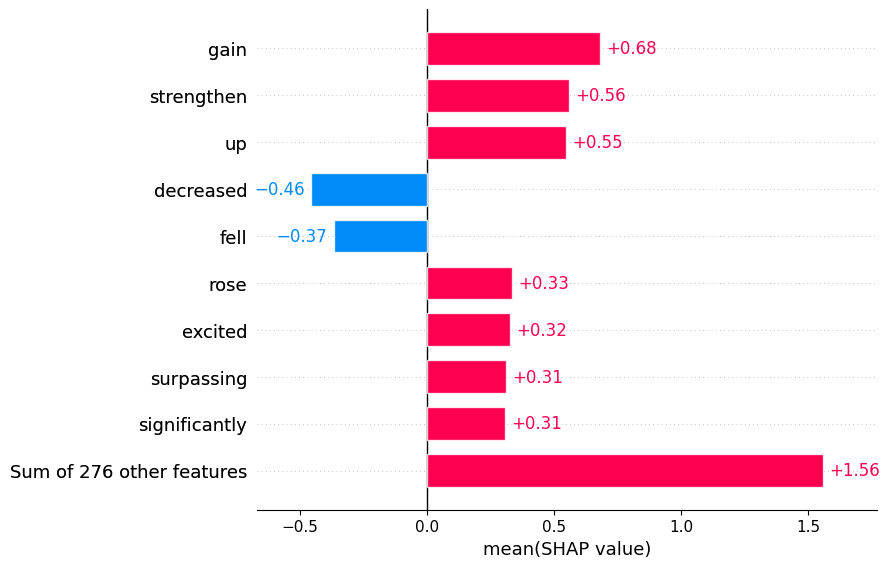

In [ ]:
# Cargar una pequeña muestra del dataset de test para análisis global
df_test = pd.read_csv("../data/processed/financial_phrasebank_clean.csv").sample(
    20, random_state=42
)
global_shap_values = explainer(df_test["sentence"].tolist())

# Gráfico de barras de importancia global para la clase 'positive'
shap.plots.bar(global_shap_values[:, :, "positive"].mean(0))

# Results Snapshot

## English
- SHAP highlights token-level contributions for each sentiment class.
- Example sentences show consistent explanations aligned with model predictions.
- Global plots reveal the most influential tokens for positive sentiment.

## Espanol
- SHAP resalta contribuciones a nivel de token por clase.
- Las frases ejemplo muestran explicaciones coherentes con la prediccion.
- Los graficos globales revelan tokens mas influyentes para sentimiento positivo.

# Conclusions

## English
- Interpretability confirms the model relies on financially meaningful terms.
- Local explanations support trust when reviewing edge cases.
- Use global insights to monitor drift in vocabulary over time.

## Espanol
- La interpretabilidad confirma el uso de terminos financieros relevantes.
- Las explicaciones locales apoyan la revision de casos limite.
- Usar insights globales para monitorear drift en vocabulario.